In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 725 ms (started: 2026-06-25 23:22:21 +02:00)


In [2]:
scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets'
)

time: 20.3 s (started: 2026-06-25 23:22:22 +02:00)


In [3]:
reader = scarf.CrH5Reader('scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5')

time: 34.5 ms (started: 2026-06-25 23:22:42 +02:00)


In [4]:
reader.nCells, reader.nFeatures

(5025, 33538)

time: 1.31 ms (started: 2026-06-25 23:22:42 +02:00)


In [5]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc='scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    chunk_size=(2000, 1000)
)
writer.dump(batch_size=1000)

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=18, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=15, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. 

  0%|                                                                                                         …

time: 11.2 s (started: 2026-06-25 23:22:42 +02:00)


In [6]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10
)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 8.45 s (started: 2026-06-25 23:22:53 +02:00)


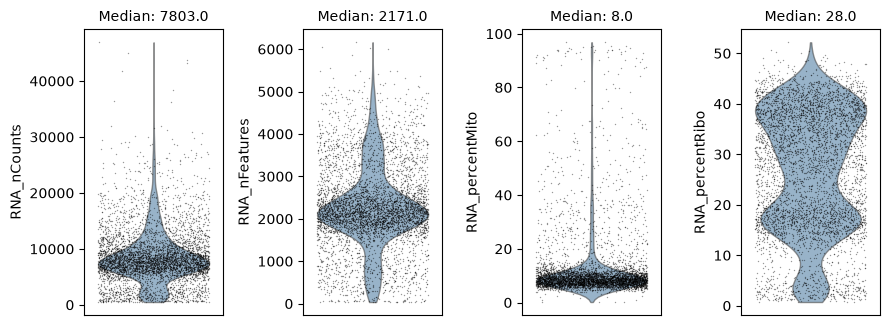

time: 2.94 s (started: 2026-06-25 23:23:01 +02:00)


In [7]:
ds.plot_cells_dists()

In [8]:
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0]
)

INFO: 597 cells flagged for filtering out using attribute RNA_nCounts


INFO: 461 cells flagged for filtering out using attribute RNA_nFeatures


INFO: 612 cells flagged for filtering out using attribute RNA_percentMito


time: 117 ms (started: 2026-06-25 23:23:04 +02:00)


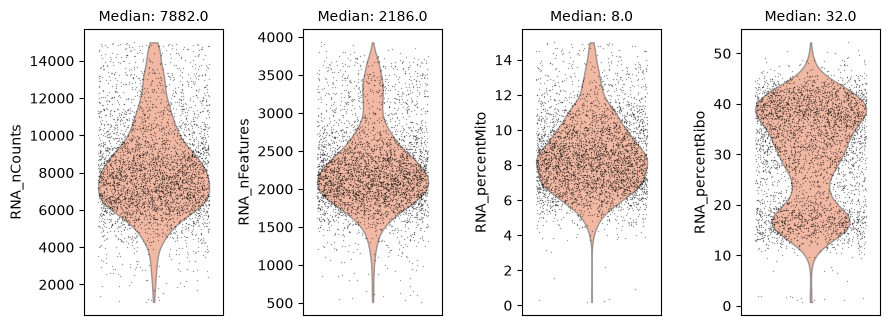

time: 1.08 s (started: 2026-06-25 23:23:05 +02:00)


In [9]:
ds.plot_cells_dists(cell_key='I', color='coral')

In [10]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_nFeatures,RNA_nCounts,RNA_percentRibo
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,3503.0,13537.0,16.783630
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,3381.0,12668.0,20.034733
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,346.0,962.0,2.494802
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,1799.0,5788.0,28.783690
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,2887.0,13186.0,35.750038


time: 112 ms (started: 2026-06-25 23:23:06 +02:00)


In [11]:
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentRibo', 'RNA_nCounts', 
            'RNA_nFeatures', 'RNA_percentMito'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 77.3 ms (started: 2026-06-25 23:23:06 +02:00)


In [12]:
ds.RNA.feats.head()

,I,ids,names,dropOuts,nCells
0,False,ENSG00000243485,MIR1302-2HG,5025,0
1,False,ENSG00000237613,FAM138A,5025,0
2,False,ENSG00000186092,OR4F5,5025,0
3,True,ENSG00000238009,AL627309.1,4976,49
4,False,ENSG00000239945,AL627309.3,5022,3


time: 68.4 ms (started: 2026-06-25 23:23:06 +02:00)


In [13]:
ds.RNA.sf

1000

time: 1.67 ms (started: 2026-06-25 23:23:06 +02:00)


INFO: Calculating summary statistics


(RNA) Computing nCells:   0%|                                                                                 …

(RNA) Computing normed_tot:   0%|                                                                             …

(RNA) Computing sigmas:   0%|                                                                                 …

INFO: Calculating HVGs


INFO: 498 genes marked as HVGs


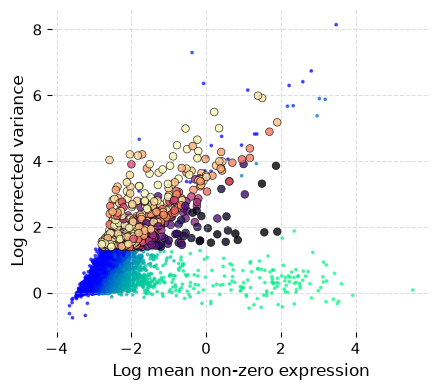

time: 18.6 s (started: 2026-06-25 23:23:06 +02:00)


In [14]:
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    min_mean=-3,
    max_mean=2,
    max_var=6
)

In [15]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,I__hvgs,stats_I_sigmas,stats_I_normed_tot,stats_I_c_var__200__0.1,stats_I_normed_n,stats_I_avg,stats_I_nz_mean
0,False,ENSG00000243485,MIR1302-2HG,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
3,True,ENSG00000238009,AL627309.1,49,4976,False,0.000196,4.593283,1.5279,33.0,0.000914,0.13919
4,False,ENSG00000239945,AL627309.3,3,5022,False,NaN,NaN,NaN,NaN,NaN,NaN


time: 298 ms (started: 2026-06-25 23:23:25 +02:00)


In [16]:
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=15,
    n_centroids=100
)

Writing data to normed__I__hvgs/data:   0%|                                                                   …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

Fitting PCA:   0%|                                                                                            …

Fitting ANN:   0%|                                                                                            …

...

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.92%


time: 22.8 s (started: 2026-06-25 23:23:25 +02:00)


In [17]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs
	completed  25  /  250 epochs


	completed  50  /  250 epochs


	completed  75  /  250 epochs
	completed  100  /  250 epochs


	completed  125  /  250 epochs
	completed  150  /  250 epochs


	completed  175  /  250 epochs
	completed  200  /  250 epochs


	completed  225  /  250 epochs


time: 4.27 s (started: 2026-06-25 23:23:48 +02:00)


In [18]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_percentMito,RNA_percentRibo,RNA_nFeatures,RNA_nCounts,RNA_UMAP2
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,9.664132,10.844353,16.783630,3503.0,13537.0,22.572268
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,-6.515604,5.975687,20.034733,3381.0,12668.0,27.572594
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,NaN,53.430353,2.494802,346.0,962.0,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,-9.782280,10.919143,28.783690,1799.0,5788.0,12.891380
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,-15.134402,7.955407,35.750038,2887.0,13186.0,-10.641832


time: 185 ms (started: 2026-06-25 23:23:52 +02:00)


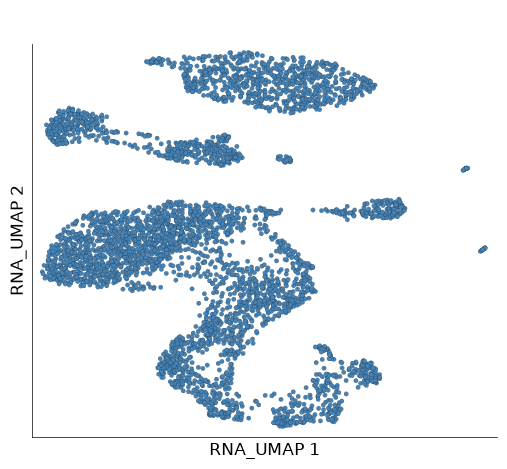

time: 236 ms (started: 2026-06-25 23:23:52 +02:00)


In [19]:
ds.plot_layout(layout_key='RNA_UMAP')

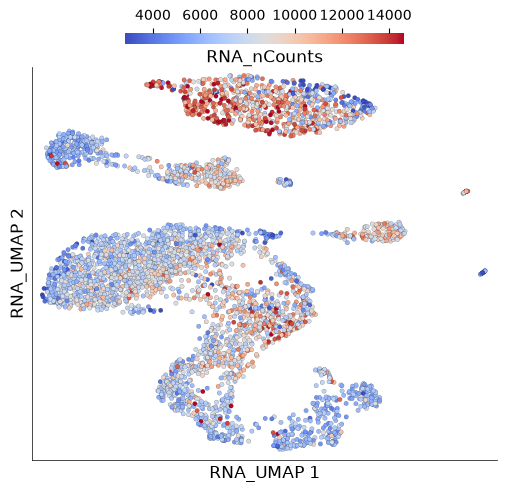

time: 518 ms (started: 2026-06-25 23:23:52 +02:00)


In [20]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    cmap='coolwarm'
)

In [21]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    parallel=True
)

Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 450: error is 2.98483 (50 iterations in 0.207777 seconds)


Iteration 499: error is 2.9837 (50 iterations in 0.172255 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.325471 sec [23.7478%] |  Repulsive forces: 1.04506 sec [76.2522%]


time: 1.73 s (started: 2026-06-25 23:23:53 +02:00)


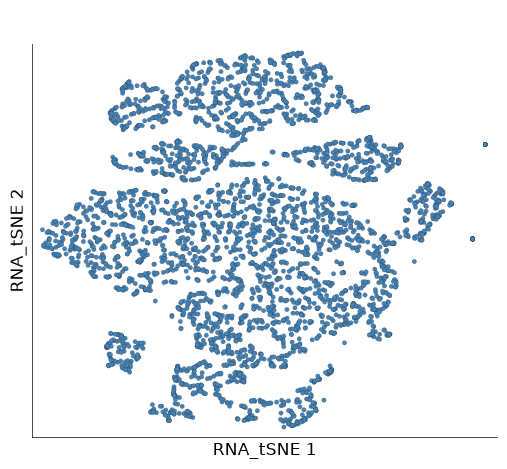

time: 278 ms (started: 2026-06-25 23:23:55 +02:00)


In [22]:
# Here we run plot_layout under exception catching because if you are not on Linux then the `run_tnse` would have failed.
try:
    ds.plot_layout(layout_key='RNA_tSNE')
except KeyError:
    print ("'RNA_tSNE1' not found in MetaData")

In [23]:
# We start with Leiden clustering
ds.run_leiden_clustering(resolution=0.5)

time: 707 ms (started: 2026-06-25 23:23:55 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


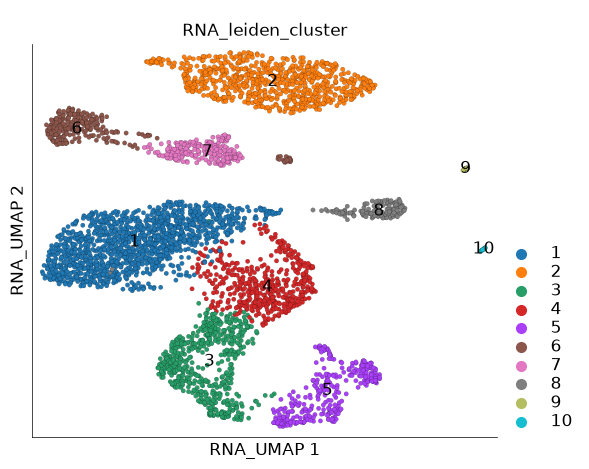

time: 553 ms (started: 2026-06-25 23:23:56 +02:00)


In [24]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster'
)

In [25]:
ds.cells.head()

,I,ids,names,RNA_tSNE1,RNA_UMAP2,RNA_nCounts,RNA_percentRibo,RNA_nFeatures,RNA_tSNE2,RNA_leiden_cluster,RNA_percentMito,RNA_UMAP1
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,-9.263619,22.572268,13537.0,16.783630,3503.0,20.011306,2,10.844353,9.664132
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,7.820420,27.572594,12668.0,20.034733,3381.0,24.845262,2,5.975687,-6.515604
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,NaN,NaN,962.0,2.494802,346.0,NaN,-1,53.430353,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,8.264343,12.891380,5788.0,28.783690,1799.0,13.414555,7,10.919143,-9.782280
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,-11.970206,-10.641832,13186.0,35.750038,2887.0,5.243791,1,7.955407,-15.134402


time: 282 ms (started: 2026-06-25 23:23:56 +02:00)


In [26]:
leiden_clusters = ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)
leiden_clusters.head()

,RNA_leiden_cluster
0,2
1,2
3,7
4,1
6,5


time: 93.1 ms (started: 2026-06-25 23:23:56 +02:00)


In [27]:
ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])

/tmp/ipykernel_76518/1807300542.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])


time: 633 ms (started: 2026-06-25 23:23:57 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


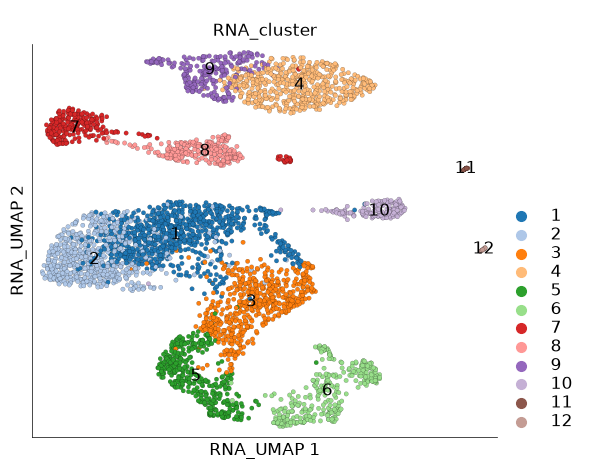

time: 612 ms (started: 2026-06-25 23:23:57 +02:00)


In [28]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster'
)

Constructing graph from dendrogram:   0%|                                                                     …

Identifying the top node for cluster:   0%|                                                                   …

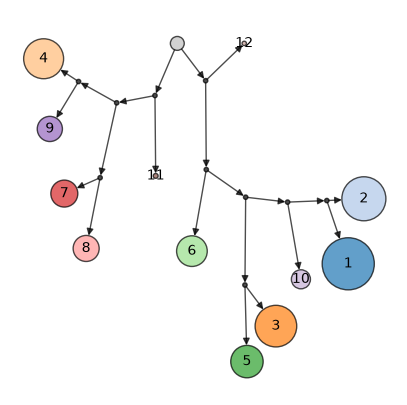

time: 818 ms (started: 2026-06-25 23:23:58 +02:00)


In [29]:
ds.plot_cluster_tree(cluster_key='RNA_cluster', width=1)

In [30]:
ds.run_marker_search(
    group_key='RNA_cluster',
    gene_batch_size=100
)

Finding markers:   0%|                                                                                        …

time: 39.9 s (started: 2026-06-25 23:23:59 +02:00)


Aggregating marker values per group:   0%|                                                                    …

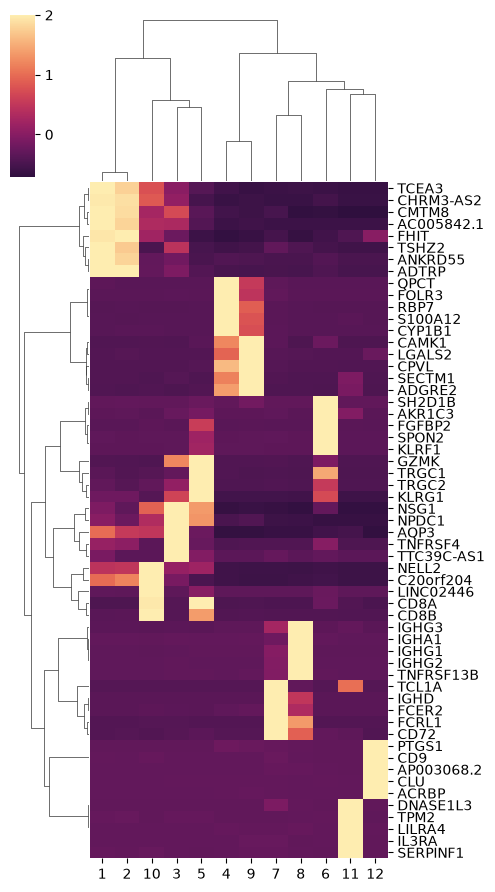

time: 3.27 s (started: 2026-06-25 23:24:39 +02:00)


In [31]:
ds.plot_marker_heatmap(
    group_key='RNA_cluster',
    topn=5,
    figsize=(5, 9)
)

In [32]:
df = ds.get_markers(
    group_key='RNA_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
df

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
0,1,TSHZ2,29849.0,0.40857,0.08223,0.01767,0.34545,0.08738,4.65416,4.171677e-79
1,1,ANKRD55,8924.0,0.39529,0.02333,0.00401,0.15974,0.02808,5.81041,6.876416e-48
2,1,ADTRP,10307.0,0.38393,0.04075,0.00948,0.23766,0.05584,4.29811,2.141098e-55
3,1,TCEA3,487.0,0.35595,0.03329,0.00804,0.22727,0.05615,4.13832,9.997316e-51
4,1,AC005842.1,20178.0,0.34883,0.02609,0.00608,0.16494,0.04006,4.28882,4.348815e-37
...,...,...,...,...,...,...,...,...,...,...
14278,1,SYK,16290.0,0.00113,0.00054,0.06404,0.00390,0.29085,0.00838,1.921593e-62
14279,1,PDLIM1,19705.0,0.00112,0.00021,0.03954,0.00260,0.16025,0.00538,1.616561e-31
14280,1,MARCH1,8323.0,0.00110,0.00071,0.09035,0.00519,0.32240,0.00788,1.133234e-70
14281,1,ZEB2,4554.0,0.00091,0.00212,0.18227,0.01688,0.45804,0.01165,1.971131e-109


time: 513 ms (started: 2026-06-25 23:24:42 +02:00)


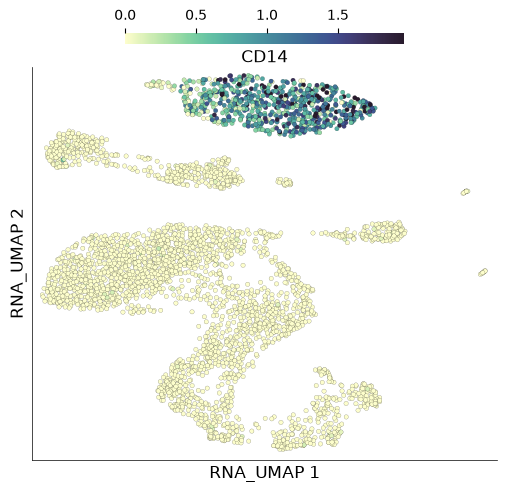

time: 892 ms (started: 2026-06-25 23:24:42 +02:00)


In [33]:
ds.plot_layout(layout_key='RNA_UMAP', color_by='CD14')